# Georeferencing Google Earth Studio aerial images

In [21]:
import os
import math
import json
import rasterio

import numpy as np
import matplotlib.pyplot as plt
import pytransform3d.rotations as pr
import pytransform3d.transformations as pt

from scipy.spatial.transform import Rotation
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from pytransform3d.plot_utils import plot_ellipsoid, make_3d_axis

In [22]:
trajectory_path = "/storage/datasets/AerialLoc/Drone2Sat/GES/Traj1_Ljubljana_150m_N-align"
trajectory_path = "/storage/datasets/AerialLoc/Drone2Sat/GES/Traj2"
trajectory_name = os.path.basename(trajectory_path)
trajectory_json_path = os.path.join(trajectory_path, f"{trajectory_name}.json")
print(trajectory_json_path)

/storage/datasets/AerialLoc/Drone2Sat/GES/Traj2/Traj2.json


In [23]:
# WGS-84 ellipsoid parameters
a = 6378137.0			# semi-major axis
b = 6356752.314245		# semi-minor axis
e2 = 1 - (b**2 / a**2) 	# squared eccentricity

In [24]:
def geodetic_to_ecef(lat_deg, lon_deg, h):
	lat = math.radians(lat_deg)
	lon = math.radians(lon_deg)
	N = a / math.sqrt(1 - e2 * math.sin(lat)**2)
	X = (N + h) * math.cos(lat) * math.cos(lon)
	Y = (N + h) * math.cos(lat) * math.sin(lon)
	Z = (N * (1 - e2) + h) * math.sin(lat)
	return X, Y, Z


def ecef_to_geodetic(x, y, z):
	"""
	Convert ECEF (x, y, z) to geodetic coordinates (lat, lon, alt)
	Returns:
		lat, lon in degrees
		alt in meters
	"""
	# Longitude
	lon = np.arctan2(y, x)
	
	# Iterative computation for latitude
	r = np.sqrt(x**2 + y**2)
	lat = np.arctan2(z, r * (1 - e2))  # initial guess
	lat_prev = 0
	while np.abs(lat - lat_prev) > 1e-12:
		lat_prev = lat
		N = a / np.sqrt(1 - e2 * np.sin(lat)**2)
		alt = r / np.cos(lat) - N
		lat = np.arctan2(z, r * (1 - e2 * N / (N + alt)))
	
	N = a / np.sqrt(1 - e2 * np.sin(lat)**2)
	alt = r / np.cos(lat) - N
	
	# Convert radians to degrees
	lat = np.degrees(lat)
	lon = np.degrees(lon)
	return lat, lon, alt

In [25]:
with open(trajectory_json_path) as f:
	data = json.load(f)

In [26]:
# Ex, Ey, Ez = [x for x in data["cameraFrames"][0]["position"].values()]
Rx, Ry, Rz = [x for x in data["cameraFrames"][0]["rotation"].values()]
lat, lon, alt = [x for x in data["cameraFrames"][0]["coordinate"].values()]
Ex, Ey, Ez = geodetic_to_ecef(lat, lon, alt)
print(Ex, Ey, Ez)
print(Rx, Ry, Rz)
print(lat, lon, alt)

4290643.0393668655 1107241.3727059767 4572700.276658878
178.03068787967462 -32.63731925654151 49.52324746123795
46.09260000788129 14.470026836474261 428.6336384175404


In [27]:
# with rasterio.open("/storage/private/MORS/SLO_DEM/SLO_DEM.tif") as src:
# 	ground_levels = src.read(1)  # read first band
# 	row, col = src.index(lon, lat)
# 	value = src.read(1)[row, col]
# 	print(f"Height at lon={lon}, lat={lat} is {value}")
# height_above_ground = alt - value

with rasterio.open("/storage/private/MORS/SLO_DEM/SLO_DEM.tif") as src:
	for val in src.sample([(lon, lat)]):
		value = val[0]
	print(f"Height at lon={lon}, lat={lat} is {value}")
height_above_ground = alt - value
print(f"Height above ground: {height_above_ground}")


Height at lon=14.470026836474261, lat=46.09260000788129 is 316.45880126953125
Height above ground: 112.17483714800915


In [28]:
# This is ECEF camera point
ecef_point = np.array([Ex, Ey, Ez])
print("ECEF:", ecef_point)

ECEF: [4290643.03936687 1107241.37270598 4572700.27665888]


[[ 6.40560697e-01  5.46641182e-01 -5.39319397e-01  4.29064304e+06]
 [ 6.34658362e-01 -7.72250831e-01 -2.89381486e-02  1.10724137e+06]
 [-4.32308636e-01 -3.23746925e-01 -8.41603928e-01  4.57270028e+06]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


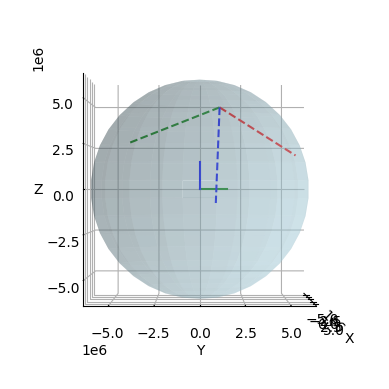

In [29]:
# Create transformation matrix
R_mat = pr.matrix_from_euler(np.radians([Rx, Ry, Rz-90]), 0, 1, 2, extrinsic=False) # NOTE: Subtract 90 degrees from Rz to ensure NED coordinate reference frame of camera
R_transform = pt.transform_from(R=R_mat, p=ecef_point)
print(R_transform)

# ECEF basis vectors
ECEF = np.eye(4)

ax = make_3d_axis(ax_s=a)
pt.plot_transform(ax, A2B=ECEF, s=a/4)
pt.plot_transform(ax, A2B=R_transform, s=a, linestyle="--")
plot_ellipsoid(ax, radii=[a, a, b], alpha=0.3, color="lightblue", wireframe=False)
ax.view_init(elev=0, azim=0, roll=0)

Floor pos: [4290567.71439231 1107221.93437763 4572619.45900185]
Image width: 334.66974036716766, Image height: 188.25172895653182
Distance from camera to plane: 112.17483714800915
[4290643.03936687 1107241.37270598 4572700.27665888] [4290643.03936687 1107241.37270598 4572700.27665888]
(46.09365348978394, 14.471327007712736, 316.4606690267101)
(46.0924474108304, 14.468043140760631, 316.46066562179476)
(46.09050722745747, 14.468484638220838, 316.46416300721467)
(46.09230533054908, 14.473380485620766, 316.46414955332875)


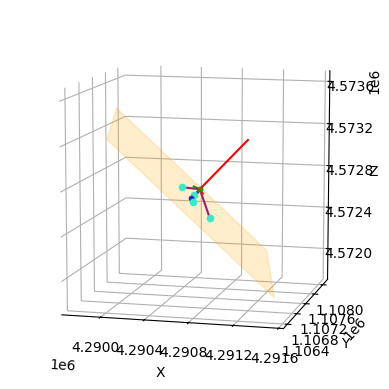

In [ ]:
# Create transformation matrix
R_mat = pr.matrix_from_euler(np.radians([Rx, Ry, Rz]), 0, 1, 2, extrinsic=False) # NOTE: DO NOT subtract 90 degrees from Rz here!!!
R_transform = pt.transform_from(R=R_mat, p=ecef_point)

# Identity transform (ECEF)
ECEF = np.eye(4)


ax = make_3d_axis(ax_s=a)
pt.plot_transform(ax, A2B=ECEF, s=a/4)
pt.plot_transform(ax, A2B=R_transform, s=100, linestyle="--")

# Plot ellipsoid (Earth)
# plot_ellipsoid(ax, radii=[a, a, b], alpha=0.1, color="lightblue", wireframe=False, n_steps=50)

# Plot the point of interest
ax.scatter(*ecef_point, color="green", s=10)


# Normal vector at that point on ellipsoid surface
x, y, z = ecef_point
n_e = np.array([
	np.cos(np.radians(lat)) * np.cos(np.radians(lon)),
	np.cos(np.radians(lat)) * np.sin(np.radians(lon)),
	np.sin(np.radians(lat))
])
ax.quiver(x, y, z, n_e[0], n_e[1], n_e[2], length=a / 10000, color="red", arrow_length_ratio=0.001)

floor_point = ecef_point - n_e * height_above_ground
print("Floor pos:", floor_point)
ax.scatter(*floor_point, color="blue", s=10)

# Two orthonormal vectors spanning the tangent plane
plane_size = 1e3  # size of patch
u = np.cross(n_e, [0, 0, 1])
u = u / np.linalg.norm(u)
v = np.cross(n_e, u)

# Grid for plane
plane_pts = []
for dx in [-1, 1]:
	for dy in [-1, 1]:
		pt_plane = floor_point + plane_size * (dx * u + dy * v)
		plane_pts.append(pt_plane)

verts = [[plane_pts[0], plane_pts[1], plane_pts[3], plane_pts[2]]]
ax.add_collection3d(Poly3DCollection(verts, alpha=0.2, color="orange"))

# Image plane size (in arbitrary units)
verticalFOV_rad = np.radians(80)
img_height = 2 * height_above_ground * np.tan(verticalFOV_rad / 2)
aspect_ratio =  data["width"] / data["height"] # example
img_width = img_height * aspect_ratio
print(f"Image width: {img_width}, Image height: {img_height}")

# Distance from camera to plane
d = height_above_ground
print(f"Distance from camera to plane: {d}")

# Corners in camera frame (z points forward)
image_corners_cam = np.array([
	[-img_width/2,  img_height/2, d],  # top-left
	[ img_width/2,  img_height/2, d],  # top-right
	[ img_width/2, -img_height/2, d],  # bottom-right
	[-img_width/2, -img_height/2, d],  # bottom-left
])

R_cam = R_transform[:3, :3]  # camera rotation
t_cam = R_transform[:3, 3]   # camera position
image_corners_world = (R_cam @ image_corners_cam.T).T + t_cam

# Transform corners to world frame
plane_point = floor_point  # any point on the plane
plane_normal = n_e         # normal vector to the plane

# ray_origin = ecef_point  # t_cam
# ray_direction = image_corners_world - t_cam  # vector from camera to corner
# ray_direction = ray_direction / np.linalg.norm(ray_direction)  # normalize
# print(ray_direction)

intersection_points = []
for corner in image_corners_world:
	ray_origin = t_cam
	ray_dir = corner - t_cam
	ray_dir = ray_dir / np.linalg.norm(ray_dir)
	
	denom = np.dot(ray_dir, plane_normal)
	if np.abs(denom) < 1e-6:
		# Ray is parallel to plane
		intersection_points.append(None)
		continue
	
	t = np.dot(plane_point - ray_origin, plane_normal) / denom
	if t < 0:
		# Intersection behind the camera
		intersection_points.append(None)
		continue
	
	intersection = ray_origin + t * ray_dir
	intersection_points.append(intersection)


for point in intersection_points:
	if point is not None:
		ax.scatter(*point, color="cyan", s=20)  # plot in cyan
		ax.plot([t_cam[0], point[0]], [t_cam[1], point[1]], [t_cam[2], point[2]], color="purple")
		print(ecef_to_geodetic(*point)) # bottom left, bottom right, top right, top left

# ---- Zoom in around location ----
zoom_size = 1e3
ax.set_xlim(ecef_point[0] - zoom_size, ecef_point[0] + zoom_size)
ax.set_ylim(ecef_point[1] - zoom_size, ecef_point[1] + zoom_size)
ax.set_zlim(ecef_point[2] - zoom_size, ecef_point[2] + zoom_size)

# Adjust view angle
ax.view_init(elev=10, azim=-75.5)
plt.show()

## Get yaw and pitch of the camera

NOTE: DO NOT add roll when creating the GES trajectory!!! It breaks the conversion (idk why).

In [18]:
def _get_rotation_matrix(n, theta):
	M = np.array([
		[n[0,0]**2, n[0,0]*n[1,0], n[0,0]*n[2,0]],
		[n[1,0]*n[0,0], n[1,0]**2, n[1,0]*n[2,0]],
		[n[2,0]*n[0,0], n[2,0]*n[1,0], n[2,0]**2]
	])
	I = np.eye(3)
	M1 = np.array([
		[0, -n[2,0], n[1,0]],
		[n[2,0], 0, -n[0,0]],
		[-n[1,0], n[0,0], 0]
	])
	R = (1 - math.cos(theta)) * M + math.cos(theta) * I + math.sin(theta) * M1
	return R

# sciR = Rotation.from_euler('XYZ', [Rx, Ry, Rz-90], degrees=True).as_matrix()
# sciR = Rotation.from_matrix(sciR)
# psi, theta, phi = sciR.as_euler('ZYX', degrees=False)

psi, theta, phi = Rotation.from_euler('XYZ', [Rx, Ry, Rz-90], degrees=True).as_euler('ZYX', degrees=False)

x_0 = np.array([[1, 0, 0]]).T
y_0 = np.array([[0, 1, 0]]).T
z_0 = np.array([[0, 0, 1]]).T

R_psi = _get_rotation_matrix(z_0, psi)
x_1 = R_psi @ x_0
y_1 = R_psi @ y_0
z_1 = R_psi @ z_0

R_theta = _get_rotation_matrix(y_1, theta)
x_2 = R_theta @ x_1
y_2 = R_theta @ y_1
z_2 = R_theta @ z_1

R_phi = _get_rotation_matrix(x_2, phi)
x_3 = R_phi @ x_2
y_3 = R_phi @ y_2
z_3 = R_phi @ z_2

In [19]:
E_0 = np.array([[0, 1, 0]]).T
N_0 = np.array([[0, 0, 1]]).T 
U_0 = np.array([[1, 0, 0]]).T

RN0 = _get_rotation_matrix(N_0, math.radians(lon))
E = RN0 @ E_0
R_E = _get_rotation_matrix(-E, math.radians(lat))
N = R_E @ N_0
U = np.cross(E, N, axis=0)

x_0 = N
y_0 = E
z_0 = -U

heading = np.arctan2( np.dot(x_3.T, y_0), np.dot(x_3.T, x_0) ).squeeze()
pitch = np.arctan2( -np.dot(x_3.T, z_0), np.sqrt(np.dot(x_3.T, x_0)**2 + np.dot(x_3.T, y_0)**2) ).squeeze()

y_2 = _get_rotation_matrix(z_0, heading) @ y_0
z_2 = _get_rotation_matrix(y_2, pitch) @ z_0
roll = np.arctan2( np.dot(y_3.T, z_2), np.dot(y_3.T, y_2) ).squeeze()

heading = np.round(np.rad2deg(heading), 3)
pitch = np.round(np.rad2deg(pitch), 3)
roll = np.round(np.rad2deg(roll), 3)
assert roll == 0, "Roll not supported!!!"

print(f"yaw: {heading}")
print(f"pitch: {pitch}")
print(f"roll: {roll}")

yaw: 152.171
pitch: 13.218
roll: 0.0
